## Imports

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

from collections import Counter
from pathlib import Path
from PIL import Image
import os

from tqdm import tqdm
import random
import shutil
import json

## Loading Dataset

In [2]:
dataset_path = Path("dataset")
dataset_classes = [name for name in os.listdir(dataset_path)]

print(f"Dataset classes are {dataset_classes}")

Dataset classes are ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']


#### Finding most common and median image sizes

In [3]:
sizes = []

for cls in dataset_classes:
    imgs_path = os.path.join(dataset_path, cls)
    files = os.listdir(imgs_path)

    for img_path in tqdm(files, desc=f"Checking Image Sizes for {cls}", total=len(files)):
        try:
            with Image.open(os.path.join(imgs_path, img_path)) as img:
                sizes.append(img.size)
        except Exception as e:
            print(f"Skipping {img_path}: {e}")

print(f"Total images: {len(sizes)}")

size_counts = Counter(sizes)

print("\nMost common image sizes:")
for size, count in size_counts.most_common(10):
    print(f"{size}: {count}")

Checking Image Sizes for Surprise: 100%|██████████| 1234/1234 [00:06<00:00, 191.89it/s]

Total images: 15453

Most common image sizes:
(205, 205): 65
(197, 197): 55
(194, 194): 54
(193, 193): 50
(228, 228): 49
(192, 192): 49
(217, 217): 47
(222, 222): 47
(256, 256): 46
(234, 234): 46


In [4]:
arr = np.array(sizes)

print(arr, arr.shape)

[[ 264  382]
 [ 177  288]
 [ 111  160]
 ...
 [ 181  206]
 [2376 3637]
 [ 259  290]] (15453, 2)


In [5]:
median_width = np.median(arr[:, 0])
median_height = np.median(arr[:, 1])

print(median_width, median_height)

293.0 349.0


### Splitting the dataset into training and testing sets

In [6]:
SPLIT_RATIO = 0.75
random.seed(42)

In [7]:
for cls in dataset_classes:
    cls_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    split_idx = int(len(images) * SPLIT_RATIO)
    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]

    os.makedirs(os.path.join("train", cls), exist_ok=True)
    os.makedirs(os.path.join("test", cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join("train", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join("test", cls, img)
        )

#### The median dimensions of the 15453 images is 293x349. We will use 300x300 for standardizing the dimensions of all images.

## Pre-Processing

#### Standardizing dimensions to 300x300 + Converting to Grayscale + Applying Normalization 

In [45]:
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),        
    transforms.Normalize([0.5], [0.5], [0.5])
])

train_set = datasets.ImageFolder(root="train", transform=train_transform)
test_set = datasets.ImageFolder(root="test", transform=test_transform)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8117647].


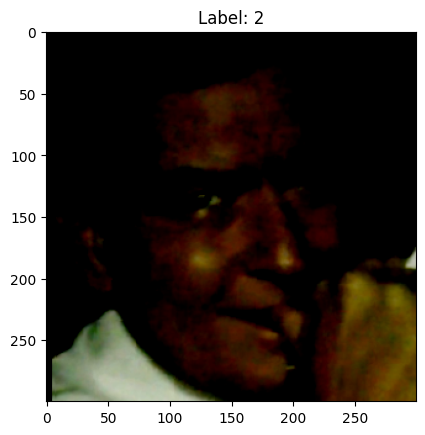

In [58]:
image, label = train_set[1900]
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.show()

In [59]:
train_loader = DataLoader(
    dataset=train_set,
    batch_size=32, 
    shuffle=True,  
)

test_loader = DataLoader(
    dataset=test_set,
    batch_size=32, 
    shuffle=False,  
)

#### Labeled Random Samples

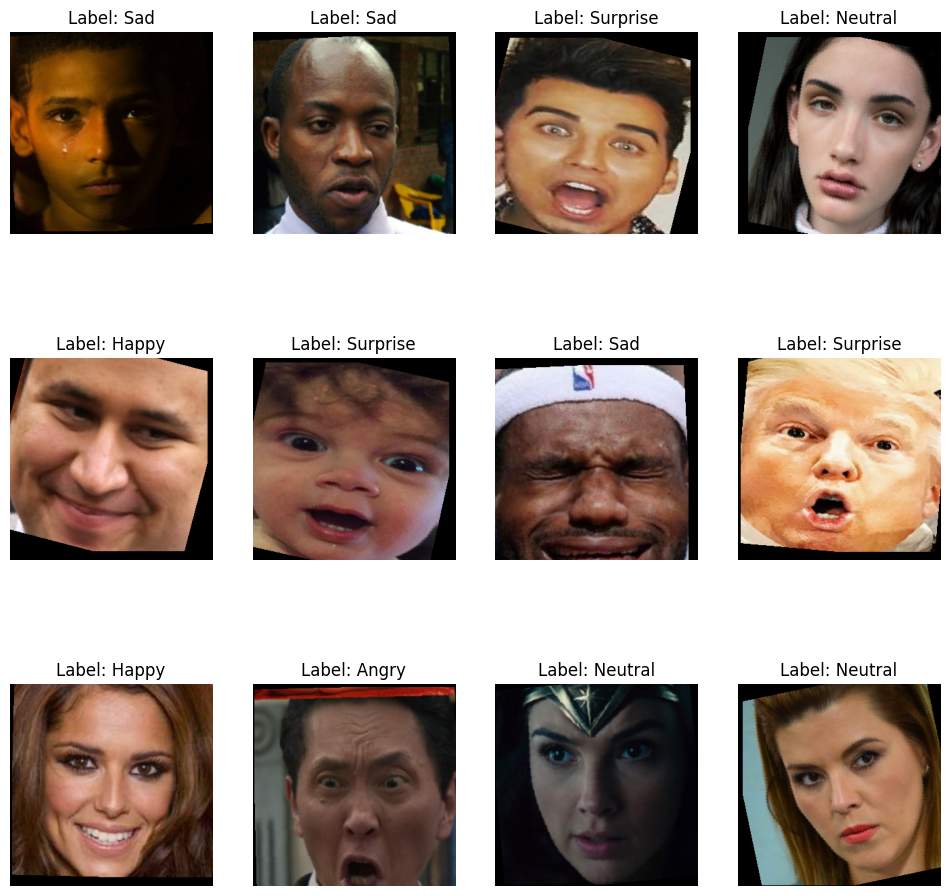

In [ ]:
train_iter = iter(train_loader)
images, labels = next(train_iter)

plt.figure(figsize=(12, 12))

for i in range(12):
    img = images[i]
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0)

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {train_set.classes[labels[i]]}")
    plt.axis("off")

plt.show()

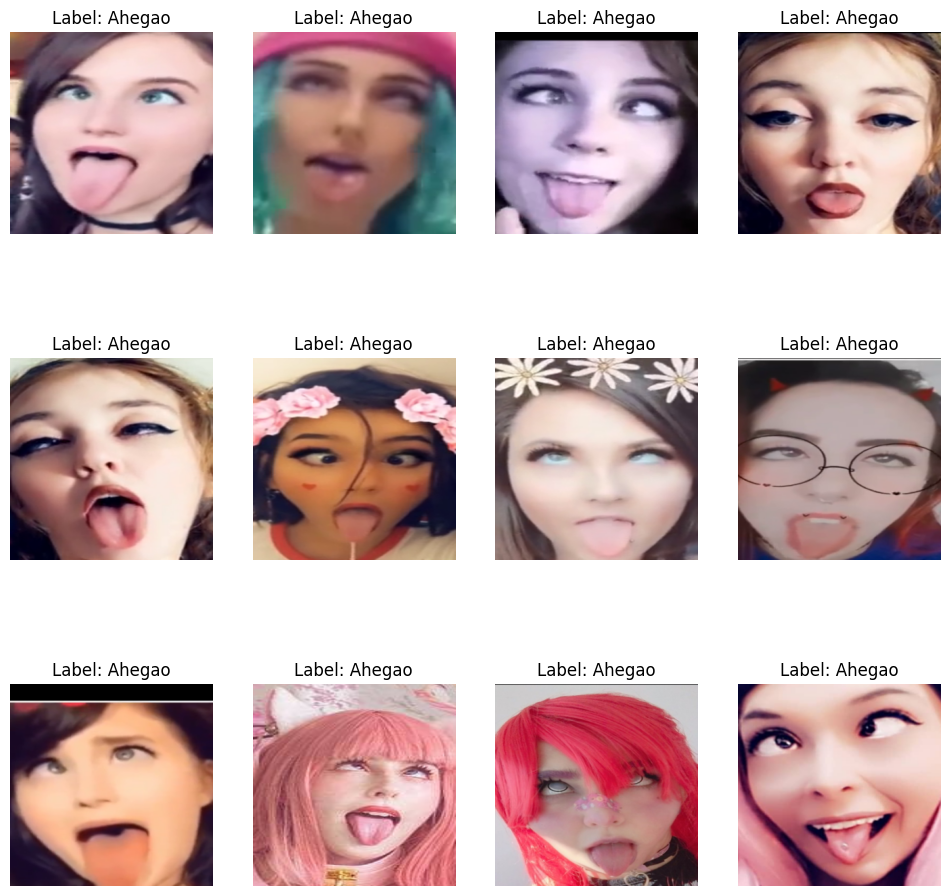

In [ ]:
test_iter = iter(test_loader)
images, labels = next(test_iter)

plt.figure(figsize=(12, 12))

for i in range(12):
    img = images[i]
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0)

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {test_set.classes[labels[i]]}")
    plt.axis("off")

plt.show()

# ============================================

## Vision Transformer

### Step 1: Patchifying each image.

In [65]:
patch_size = 15
channels = 3
img_size = 300
embed_dim = 192 #(patch_size ** 2) * channels  #400
num_of_patches = int((img_size / patch_size) ** 2)  #225

In [66]:
class PatchEmbedding(nn.Module):
    def __init__(self, embed_dim, patch_size, num_patches, channels):
        super().__init__()
        self.patcher = nn.Sequential(
            nn.Conv2d(
                in_channels=channels,
                out_channels=embed_dim,
                kernel_size=patch_size,
                stride=patch_size,
            ),                  
            nn.Flatten(2))

        self.class_token = nn.Parameter(torch.randn(size=(1, 1, embed_dim)), requires_grad=True)
        self.position_embeddings = nn.Parameter(torch.randn(size=(1, num_patches+1, embed_dim)), requires_grad=True)

    def forward(self, x):
        class_token = self.class_token.expand(x.shape[0], -1, -1)

        x = self.patcher(x).permute(0, 2, 1)
        x = torch.cat([class_token, x], dim=1)
        x = self.position_embeddings + x 
        
        return x

### Step 2: Vision Transformer Model

In [67]:
num_classes = 6
num_of_heads = 3
num_of_encoders = 8

In [68]:
class ViT(nn.Module):
    def __init__(self, num_patches, img_size, num_classes, patch_size, embed_dim, num_encoders, num_heads, channels):
        super().__init__()
        self.embeddings_block = PatchEmbedding(embed_dim, patch_size, num_patches, channels)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, activation="gelu", batch_first=True, norm_first=True)
        self.encoder_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_encoders)

        self.mlp_head = nn.Sequential(
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, embed_dim),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(embed_dim, num_classes)
            )

    def forward(self, x):
        x = self.embeddings_block(x)
        x = self.encoder_blocks(x)
        x = self.mlp_head(x[:, 0, :])
        return x

### Step 3: Training

In [69]:
vit_model = ViT(num_of_patches, img_size, num_classes, patch_size, embed_dim, num_of_encoders, num_of_heads, channels).to(device)
vit_model.to(device)

C:\Users\LEGION\AppData\Local\Temp\ipykernel_19744\3491855081.py:7: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_encoders)


ViT(
  (embeddings_block): PatchEmbedding(
    (patcher): Sequential(
      (0): Conv2d(3, 192, kernel_size=(15, 15), stride=(15, 15))
      (1): Flatten(start_dim=2, end_dim=-1)
    )
  )
  (encoder_blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
        )
        (linear1): Linear(in_features=192, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=192, bias=True)
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((192,), eps=1e-05, elementwise

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, scheduler):
    model.train()

    total_loss = 0
    correct = 0
    total_samples = 0

    loop = tqdm(dataloader, desc="Training", leave=False)

    for img, labels in loop:
        img = img.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(img)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples

    return avg_loss, accuracy

In [72]:
def evaluate(model, dataloader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    correct = 0
    total_samples = 0

    loop = tqdm(dataloader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for img, labels in loop:
            img = img.to(device)

            outputs = model(img)
            preds = outputs.argmax(dim=1)

            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds.cpu() == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = correct / total_samples

    return accuracy, all_labels, all_predictions

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=3e-4, weight_decay=0.01)

epochs = 100
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=1000
)

best_acc = 0

train_losses = []
train_accuracies = []
test_accuracies = []
lrs = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        vit_model,
        train_loader,
        criterion,
        optimizer,
        device,
        scheduler
    )

    test_acc, y_true, y_pred = evaluate(
        vit_model,
        test_loader,
        device
    )

    #scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    lrs.append(optimizer.param_groups[0]["lr"])


    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Test Acc: {test_acc:.4f}")

    # save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(vit_model.state_dict(), "best_vit3.pth")


with open("vit_training_log3.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,
        "learning_rates": lrs
    }, f)
print("\nTraining finished and results are saved!")

Epoch 1
Train Loss: 1.6550
Train Acc: 0.2988
Test Acc: 0.3120


Epoch 2
Train Loss: 1.6300
Train Acc: 0.3210
Test Acc: 0.3365


Epoch 3
Train Loss: 1.6124
Train Acc: 0.3377
Test Acc: 0.3417


Epoch 4
Train Loss: 1.5831
Train Acc: 0.3568
Test Acc: 0.3800


Epoch 5
Train Loss: 1.5583
Train Acc: 0.3652
Test Acc: 0.3831


...

Epoch 96
Train Loss: 0.8503
Train Acc: 0.7764
Test Acc: 0.6818


Epoch 97
Train Loss: 0.8538
Train Acc: 0.7716
Test Acc: 0.6811


Epoch 98
Train Loss: 0.8548
Train Acc: 0.7730
Test Acc: 0.6805


Epoch 99
Train Loss: 0.8526
Train Acc: 0.7725
Test Acc: 0.6803


Epoch 100
Train Loss: 0.8530
Train Acc: 0.7788
Test Acc: 0.6811

Training finished and results are saved!


## Evaluation

#### Learning Curves

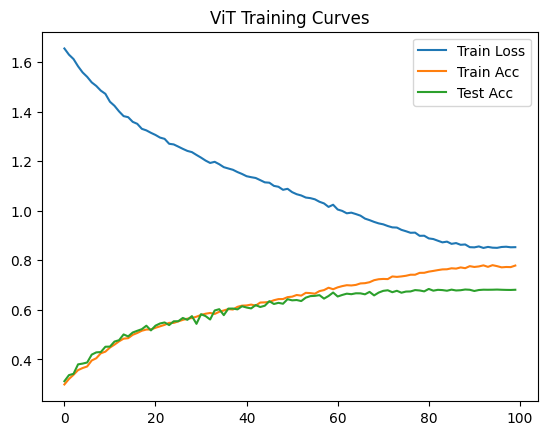

In [74]:
import matplotlib.pyplot as plt

epochs_range = range(len(train_losses))

plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, test_accuracies, label="Test Acc")

plt.legend()
plt.title("ViT Training Curves")
plt.show()

#### Confusion Matrix

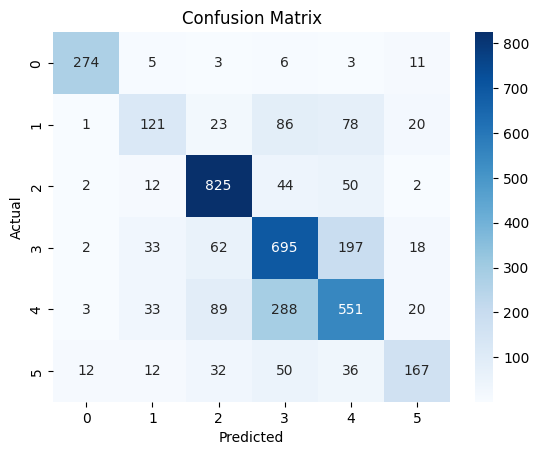

Number of misclassified examples: 1233


In [75]:
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

misclassified_indices = np.where(np.array(y_true) != np.array(y_pred))[0]
print(f'Number of misclassified examples: {len(misclassified_indices)}')

#### Classification Report

In [76]:
report = classification_report(y_true, y_pred, target_names=test_set.classes)
print(report)

              precision    recall  f1-score   support

      Ahegao       0.93      0.91      0.92       302
       Angry       0.56      0.37      0.44       329
       Happy       0.80      0.88      0.84       935
     Neutral       0.59      0.69      0.64      1007
         Sad       0.60      0.56      0.58       984
    Surprise       0.70      0.54      0.61       309

    accuracy                           0.68      3866
   macro avg       0.70      0.66      0.67      3866
weighted avg       0.68      0.68      0.68      3866



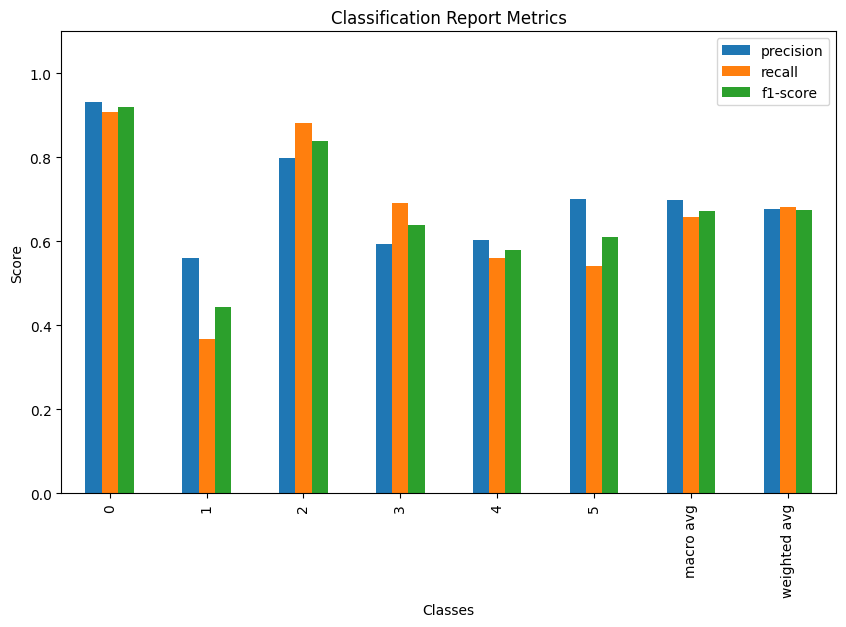

In [77]:
v_report = classification_report(y_true, y_pred, output_dict=True)

df = pd.DataFrame(v_report).transpose()
metrics = ['precision', 'recall', 'f1-score']
plt.figure(figsize=(10, 6))
df.loc[df.index != 'accuracy', metrics].plot(kind='bar', ax=plt.gca())
plt.title("Classification Report Metrics")
plt.xlabel("Classes")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.show()

#### Training Learning Curve

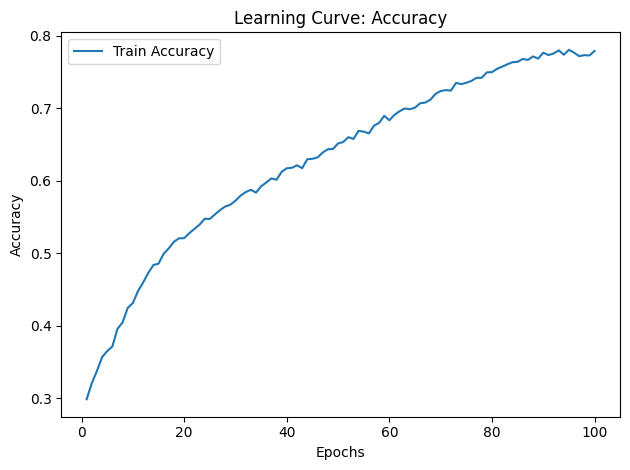

In [78]:
plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Learning Curve: Accuracy')
plt.legend()

plt.tight_layout()
plt.show()